In [1]:
import argparse
import logging
import os
import pathlib
import pprint
import shutil

# Configure logging FIRST, before any other imports
logging.basicConfig(
    filename="tracking.log",
    level=logging.WARNING,  # Changed from DEBUG to WARNING
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
)
# Suppress ultrack logging completely
logging.getLogger("ultrack").setLevel(logging.ERROR)
logging.getLogger("ultrack.utils").setLevel(logging.ERROR)
logging.getLogger("ultrack.utils.cuda").setLevel(logging.ERROR)
logging.getLogger("ultrack.utils.edge").setLevel(logging.ERROR)

import json
from pathlib import Path

import dask.array as da
import matplotlib.pyplot as plt
import napari
import natsort
import numpy as np
import optuna
import pandas as pd
import scipy.ndimage as ndi
import seaborn as sns
import tifffile
import torch
from napari.utils.notebook_display import nbscreenshot
from PIL import Image
from rich.pretty import pprint
from tifffile import imread
from ultrack import (
    MainConfig,
    add_flow,
    link,
    segment,
    solve,
    to_ctc,
    to_tracks_layer,
    track,
    tracks_to_zarr,
)
from ultrack.config import MainConfig
from ultrack.imgproc import detect_foreground, robust_invert
from ultrack.imgproc.flow import (
    advenct_from_quasi_random,
    timelapse_flow,
    trajectories_to_tracks,
)
from ultrack.tracks import close_tracks_gaps
from ultrack.tracks.stats import tracks_df_movement
from ultrack.utils import estimate_parameters_from_labels, labels_to_contours
from ultrack.utils.array import array_apply, create_zarr
from ultrack.utils.cuda import on_gpu

os.environ["OMP_NUM_THREADS"] = "8"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import logging

logging.getLogger("ultrack").setLevel(logging.INFO)

import napari
from napari.utils.notebook_display import nbscreenshot
from timelapse_utils.file_utils.notebook_init_utils import (
    bandicoot_check,
    init_notebook,
)

root_dir, in_notebook = init_notebook()
if in_notebook:
    import tqdm.notebook as tqdm
else:
    import tqdm

/home/lippincm/miniforge3/envs/timelapse_segmentation_env/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
def clear_gpu_memory():
    """
    A little function to clear gpu memory
    """

    torch.cuda.empty_cache()


clear_gpu_memory()

# begin time, CPU memory peak usage and GPU memory peak usage tracking
import time
import tracemalloc

import pynvml

pynvml.nvmlInit()

start_time = time.time()
tracemalloc.start()
handle = pynvml.nvmlDeviceGetHandleByIndex(0)  # Assuming you want to track GPU 0

In [ ]:
if not in_notebook:
    print("Running as script")
    # set up arg parser
    parser = argparse.ArgumentParser(description="Segment the nuclei of a tiff image")

    parser.add_argument(
        "--well_fov",
        type=str,
        help="Path to the input directory containing the tiff images",
    )
    parser.add_argument(
        "--generate_gif",
        action="store_true",
        help="Whether to generate a gif of the tracks",
    )

    args = parser.parse_args()
    well_fov = args.well_fov
    generate_gif = args.generate_gif
    if generate_gif:
        print("GIF generation is enabled, this may take a while...")

else:
    print("Running in a notebook")
    well_fov = "B2_1"  # example well_fov
    generate_gif = False

image_base_dir = bandicoot_check(
    root_dir=root_dir,
    bandicoot_mount_path=pathlib.Path(os.path.expanduser("~/mnt/bandicoot")).resolve(),
)

raw_image_input_dir = pathlib.Path(
    image_base_dir
    / "live_cell_timelapse_pyroptosis_project_data"
    / "processed_data"
    / "1.illumination_corrected_files"
    / well_fov
).resolve(strict=True)

segmentation_mask_input_dir = pathlib.Path(
    image_base_dir
    / "live_cell_timelapse_pyroptosis_project_data"
    / "processed_data"
    / "2.cell_segmentation_masks"
    / well_fov
).resolve()

config_output_path = "../results/ultrack_config.json"
with open(config_output_path, "r") as f:
    config_dict = json.load(f)
config = MainConfig.parse_obj(config_dict)

temporary_output_dir = pathlib.Path("../tmp_output").resolve()
figures_output_dir = pathlib.Path("../figures").resolve()
results_output_dir = pathlib.Path("../results").resolve()
temporary_output_dir.mkdir(exist_ok=True)
figures_output_dir.mkdir(exist_ok=True)
results_output_dir.mkdir(exist_ok=True)
pprint(config)

Running in a notebook


MainConfig(
│   data_config=DataConfig(
│   │   n_workers=1,
│   │   working_dir=PosixPath('.'),
│   │   database='sqlite',
│   │   address=None,
│   │   in_memory_db_id=0
│   ),
│   segmentation_config=SegmentationConfig(
│   │   min_area=100,
│   │   max_area=1000000,
│   │   n_workers=1,
│   │   min_frontier=0.0,
│   │   threshold=0.5,
│   │   max_noise=0.0,
│   │   random_seed='frame',
│   │   ws_hierarchy=<function watershed_hierarchy_by_area at 0x7f272619fe20>,
│   │   anisotropy_penalization=0.0
│   ),
│   linking_config=LinkingConfig(
│   │   max_distance=15.0,
│   │   n_workers=1,
│   │   max_neighbors=5,
│   │   distance_weight=0.0,
│   │   z_score_threshold=5.0
│   ),
│   tracking_config=TrackingConfig(
│   │   solver_name='',
│   │   appear_weight=-0.001,
│   │   disappear_weight=-0.001,
│   │   division_weight=-0.001,
│   │   image_border_size=None,
│   │   n_threads=-1,
│   │   window_size=None,
│   │   overlap_size=1,
│   │   solution_gap=0.001,
│   │   time_limit=36000,
│   │   method=0,
│   │   link_function='power',
│   │   power=4,
│   │   bias=-0.0,
│   │   dismiss_weight_guess=None,
│   │   include_weight_guess=None
│   )
)

In [4]:
file_extensions = {".tif", ".tiff"}
# get all the raw image files
raw_images = list(raw_image_input_dir.glob("*"))
raw_images = [f for f in raw_images if f.suffix in file_extensions]
raw_images = sorted(raw_images)

# get all the segmentation mask files
segmentation_masks = list(segmentation_mask_input_dir.glob("*"))
segmentation_masks = [f for f in segmentation_masks if f.suffix in file_extensions]
segmentation_masks = sorted(segmentation_masks)


nuclei_files = [f for f in raw_images if "C4" in f.name.split("_")[3]]
mask_files = [f for f in segmentation_masks if "nuclei" in f.name]

nuclei_files = natsort.natsorted(nuclei_files)
mask_files = natsort.natsorted(mask_files)

print(f"Found {len(mask_files)} segmentation mask files in the input directory")
print(f"Found {len(nuclei_files)} nuclei files in the input directory")

Found 102 segmentation mask files in the input directory
Found 102 nuclei files in the input directory


In [5]:
# read in the masks and create labels
masks = []
for tiff_file in mask_files:  # only read in the first 5 files to save time and memory
    img = tifffile.imread(tiff_file)
    masks.append(img)

masks = np.array(masks)

nuclei = []
for tiff_file in nuclei_files:
    img = tifffile.imread(tiff_file)
    nuclei.append(img)
nuclei = np.array(nuclei)

In [6]:
image_dims = nuclei[0].shape
timelapse_raw = np.zeros(
    (nuclei.shape[0], image_dims[0], image_dims[1]), dtype=np.uint16
)

In [7]:
detections = np.zeros((len(masks), image_dims[0], image_dims[1]), dtype=np.uint16)
edges = np.zeros((len(masks), image_dims[0], image_dims[1]), dtype=np.uint16)
for frame_index, frame in tqdm.tqdm(
    enumerate(masks), total=len(masks), desc="Processing frames"
):
    detections[frame_index, :, :], edges[frame_index, :, :] = labels_to_contours(frame)
print(detections.shape, edges.shape)

clear_gpu_memory()

Processing frames:   0%|          | 0/102 [00:00<?, ?it/s]

Converting labels to contours: 100%|██████████| 2000/2000 [00:02<00:00, 802.39it/s]


(102, 2000, 2000) (102, 2000, 2000)


Estimating params.: 100%|██████████| 102/102 [00:27<00:00,  3.76it/s]


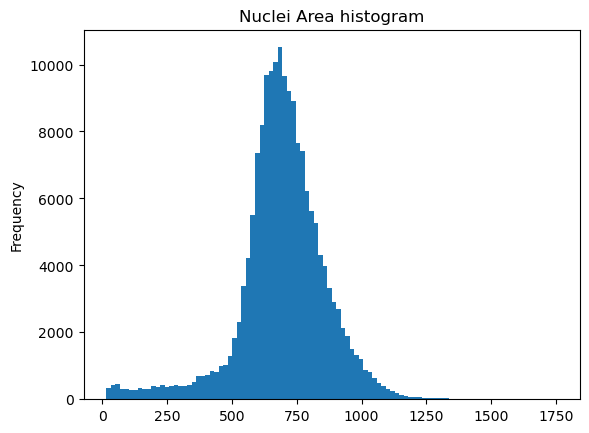

In [8]:
params_df = estimate_parameters_from_labels(masks, is_timelapse=True)
if in_notebook:
    params_df["area"].plot(kind="hist", bins=100, title="Nuclei Area histogram")

In [9]:
track(
    foreground=detections,
    edges=edges,
    config=config,
    overwrite=True,
)

Linking nodes.: 100%|██████████| 101/101 [01:18<00:00,  1.28it/s]


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2789273
Academic license 2789273 - for non-commercial use only - registered to mi___@cuanschutz.edu
Using Gurobi solver
Solving ILP batch 0
Constructing ILP ...
Set parameter TimeLimit to value 36000
Solving ILP ...
Set parameter NodeLimit to value 1073741824
Set parameter SolutionLimit to value 1073741824
Set parameter IntFeasTol to value 1e-06
Set parameter FeasibilityTol to value 1e-06
Set parameter OptimalityTol to value 1e-06
Set parameter Method to value 3
Set parameter Seed to value 0
Set parameter PoolSolutions to value 10
Set parameter MIPGap to value 0.001
Set parameter MIPGapAbs to value 1e-10
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Pop!_OS 22.04 LTS")

CPU model: AMD Ryzen 9 5900X 12-Core Processor, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 24 logical processors, using up to 24 threads

Non-default parameters:
NodeLimit  1073741824
SolutionLimit  10

In [10]:
tracks_df, graph = to_tracks_layer(config)
tracks_df = close_tracks_gaps(
    tracks_df=tracks_df,
    max_gap=2,
    max_radius=50,
    spatial_columns=["y", "x"],
)

/home/lippincm/miniforge3/envs/timelapse_segmentation_env/lib/python3.10/site-packages/ultrack/tracks/gap_closing.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  starts = starting_tracklets.groupby("track_id").apply(
/home/lippincm/miniforge3/envs/timelapse_segmentation_env/lib/python3.10/site-packages/ultrack/tracks/gap_closing.py:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ends = ending_tracks.groupby("t

In [11]:
labels = tracks_to_zarr(config, tracks_df)
# save the tracks as parquet
tracks_df.to_parquet(
    f"{results_output_dir}/{well_fov}_tracks.parquet",
)
print(tracks_df["track_id"].nunique())
print(f"Found {tracks_df['track_id'].nunique()} unique tracks in the dataset.")
tracks_df.head()

Exporting segmentation masks: 100%|██████████| 102/102 [00:13<00:00,  7.84it/s]


18927
Found 18927 unique tracks in the dataset.


,track_id,t,y,x,id,parent_track_id,parent_id
0,1,0.0,10.0,155.0,1000003.0,-1,-1.0
1,1,1.0,3.0,164.0,2000001.0,-1,1000003.0
2,1,2.0,6.0,153.0,3000001.0,-1,2000001.0
3,1,3.0,2.0,141.0,4000003.0,-1,3000001.0
4,1,4.0,1.0,134.0,5000003.0,-1,4000003.0


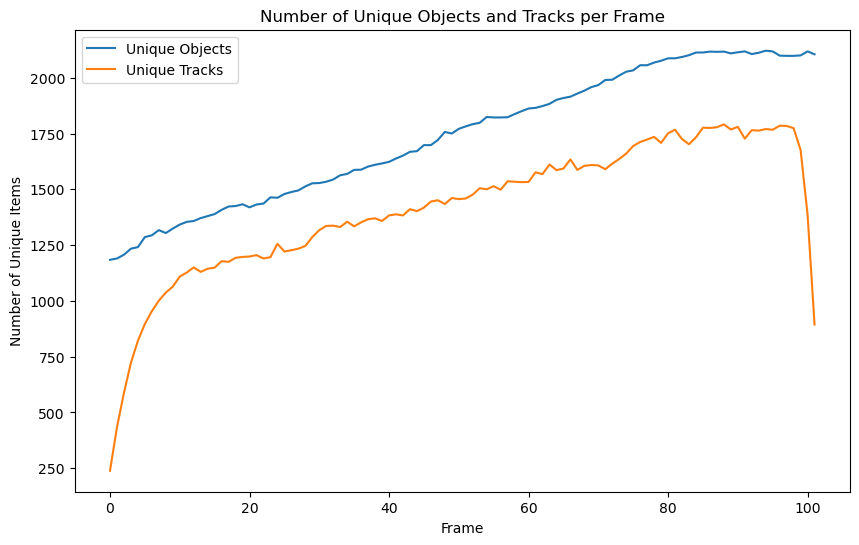

In [12]:
if in_notebook:
    # get the number of unique objects per frame and the unique tracks per frame
    unique_objects_per_frame_dict = {
        "frame": [],
        "n_unique_objects": [],
    }
    for frame_number, frame_image in enumerate(masks):
        unique_objects_per_frame_dict["frame"].append(frame_number)
        unique_objects_per_frame_dict["n_unique_objects"].append(
            np.unique(frame_image).size
        )
    unique_objects_per_frame_df = pd.DataFrame(unique_objects_per_frame_dict)

    # plot the number of unique objects per frame and the unique tracks per frame
    objects_per_frame = tracks_df.groupby("t")["track_id"].nunique()
    plt.figure(figsize=(10, 6))
    # plot the first line (unique objects per frame)
    plt.plot(
        unique_objects_per_frame_df["frame"],
        unique_objects_per_frame_df["n_unique_objects"],
        label="Unique Objects",
    )
    # plot the second line (unique tracks per frame)
    plt.plot(objects_per_frame.index, objects_per_frame.values, label="Unique Tracks")
    plt.title("Number of Unique Objects and Tracks per Frame")
    plt.xlabel("Frame")
    plt.ylabel("Number of Unique Items")
    plt.legend()
    plt.savefig(
        f"{figures_output_dir}/{well_fov}_unique_objects_and_tracks_per_frame.png"
    )
    plt.show()

In [13]:
if generate_gif:
    tracks_df.reset_index(drop=True, inplace=True)
    tracks = np.zeros((len(masks), image_dims[0], image_dims[1]), dtype=np.uint16)
    cum_tracks_df = tracks_df.copy()
    timepoints = tracks_df["t"].unique()

    # zero out the track_df for plotting
    cum_tracks_df = cum_tracks_df.loc[cum_tracks_df["t"] == -1]
    for frame_index, _ in enumerate(nuclei):
        tmp_df = tracks_df.loc[tracks_df["t"] == frame_index]
        cum_tracks_df = pd.concat([cum_tracks_df, tmp_df])
        plt.figure(figsize=(6, 3))
        plt.subplot(121)
        plt.imshow(detections[frame_index, :, :], cmap="prism")
        plt.title("Detections")
        plt.axis("off")

        plt.subplot(122)
        sns.lineplot(
            data=cum_tracks_df,
            x="x",
            y="y",
            hue="track_id",
            legend=False,
            palette="Spectral",
            linewidth=0.8,
            alpha=0.8,
        )
        plt.imshow(detections[frame_index, :, :], cmap="prism", alpha=0.3)
        plt.title(f"Frame {frame_index}")
        plt.axis("off")

        plt.tight_layout()
        plt.savefig(f"{temporary_output_dir}/tracks_{frame_index}.png")
        plt.close()
    # load each image
    files = [f for f in temporary_output_dir.glob("*.png")]
    files = sorted(files, key=lambda x: int(x.stem.split("_")[1]))
    frames = [Image.open(f) for f in files]
    fig_path = figures_output_dir / f"{well_fov}_tracks.gif"
    # plot the line of each track in matplotlib over a gif
    # get the tracks
    # save the frames as a gif
    frames[0].save(
        fig_path, save_all=True, append_images=frames[1:], duration=100, loop=0
    )

In [14]:
# clean up tracking files
# remove temporary_output_dir
shutil.rmtree(temporary_output_dir)

track_db_path = pathlib.Path("data.db").resolve()
metadata_toml_path = pathlib.Path("metadata.toml").resolve()
if track_db_path.exists():
    track_db_path.unlink()
if metadata_toml_path.exists():
    metadata_toml_path.unlink()

In [15]:
clear_gpu_memory()

In [ ]:
end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
mem_info = pynvml.nvmlDeviceGetMemoryInfo(handle)
print(f"Time taken for tracking: {end_time - start_time:.2f} seconds")
print(f"Peak memory used: {peak / (1024**3):.2f} GB")
print(f"GPU Memory used: {mem_info.used / (1024**3):.2f} GB")

Time taken for tracking: 85050.94 seconds
Peak memory used: 34.81 GB
GPU Memory used: 5.81 GB


: 